# Figure 2 burst compilation

Notebook-first assembly for Figure 2 based on `burst_analysis.ipynb` and the `stimRemovalNull` dataset. The notebook keeps the expensive burst-derived data in a cache, then uses composable plotting helpers for fast layout iteration.

In [17]:
%matplotlib inline

from pathlib import Path
import gc
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import PrepConfig, RestingActivityDataset
from ephax.metrics.layout_grid import compute_grid_avghz_per_recording
from ephax.metrics import (
    BurstActivityConfig,
    activity_wave_supplementary_tables,
    build_activity_state_kde_for_div,
    build_aggregate_wave_for_div as build_wave_aggregate_for_div,
    build_burst_activity_stats_for_div,
    build_highest_activity_peak_time_map,
    build_single_recording_burst_panels,
    load_cached_wave_for_div as load_cached_wave_summary_for_div,
    p_to_stars,
    wave_fit_diagnostics,
    wave_settings_from_config,
)
from ephax.plotting import (
    PAPER_COLORS,
    apply_paper_style,
    compose_figure,
    draw_activity_state_ifr_kde_histograms,
    draw_electrode_peak_time_map,
    draw_grid_avghz_panel,
    draw_high_activity_burst_windows,
    draw_population_ifr_summary,
    draw_wave_bootstrap_panel,
    draw_wave_timing_panel,
    export_figure,
    figure,
    grid_avghz_panel_axes_factory,
    panel,
    population_ifr_summary_axes_factory,
)

apply_paper_style()
plt.rcParams["figure.dpi"] = 170
np.random.seed(0)


## Configuration and cache

Set `FORCE_RERUN = True` after changing analysis parameters. The cache stores only derived objects needed by the Figure 2 panels, not every intermediate high-resolution trace.

In [ ]:
FORCE_RERUN = False
SAVE_FIGURE = True
CACHE_VERSION = "figure2_burst_v5_supp_all_divs"

DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"
OUTPUT_DIR = repo_root / "outputs" / "figure2_burst"
CACHE_PATH = OUTPUT_DIR / "figure2_burst_cache.pkl"
WAVE_CACHE_ROOT = repo_root / "outputs" / "stim_removal_null_wave_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WELLS = [0, 1, 2, 3, 4, 5]
DIVS = [12, 21]
SUPP_DIVS = [12, 14, 21]
EXAMPLE_WELL = 0
START_SEC = 0.0
END_SEC = 600.0
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

IFR_GRID_HZ = 50.0
IFR_MAX_HZ = 1000.0
SMOOTH_SIGMA_SEC = 0.15
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0
BURST_WINDOW_PAD_SEC = 0.40

WAVE_DIV = 12
WAVE_X_BIN_UM = 300.0
WAVE_PEAK_SEARCH_START_MS = -15.0
WAVE_PEAK_SEARCH_STOP_MS = 20.0
WAVE_TRACE_SMOOTH_SIGMA_MS = 2.0
WAVE_MIN_ELECTRODES_PER_BIN = 5
WAVE_MIN_EVENTS_PER_BIN = 5
WAVE_BOOTSTRAP_REPS = 2000
WAVE_RANDOM_SEED = 0
SUPP_BOOTSTRAP_REPS = 2000
SUPP_RANDOM_SEED = 0
WAVE_FORCE_RECOMPUTE = False
AGGREGATE_WAVE_FORCE_RECOMPUTE = False

GRID_SIZE_UM = 50.0
GRID_INTERPOLATE = False

STATE_LABELS = {
    "low_activity": "Low activity",
    "high_activity": "High activity",
    "burst": "Burst",
}
STATE_COLORS = {
    "low_activity": PAPER_COLORS["low_activity"],
    "high_activity": PAPER_COLORS["high_activity"],
    "burst": PAPER_COLORS["burst"],
}

In [19]:
def recording_path(well, div):
    return DATA_ROOT / f"well{int(well)}" / FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def recording_spec(well, div):
    path = recording_path(well, div)
    if not path.exists():
        raise FileNotFoundError(f"Missing stimRemovalNull file: {path}")
    return {
        "well": int(well),
        "div": int(div),
        "path": path,
        "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
        "label": f"well {int(well)} DIV {int(div)}",
    }


def rebase_dataset_clock(ds):
    for rec in ds.recordings:
        offset_s = float(rec.start_time)
        rec.spikes = {**rec.spikes, "time": np.asarray(rec.spikes["time"], dtype=float) - offset_s}
        rec.end_time = float(rec.end_time) - offset_s
        rec.start_time = 0.0
    return ds


def load_recording(spec):
    with np.load(spec["path"], allow_pickle=True) as data:
        sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
        frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
        rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
    file_info = [(str(spec["path"]), rec_t0 + START_SEC, rec_t0 + END_SEC, int(spec["well"]))]
    ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(MIN_AMP))
    return rebase_dataset_clock(ds)


def load_dataset_for_specs(specs):
    file_info = []
    for spec in specs:
        with np.load(spec["path"], allow_pickle=True) as data:
            sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
            frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
            rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
        file_info.append((str(spec["path"]), rec_t0 + START_SEC, rec_t0 + END_SEC, int(spec["well"])))
    ds = RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(MIN_AMP))
    return rebase_dataset_clock(ds)


def select_refs(ds):
    prep = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
    return ds.select_ref_electrodes(prep)[0]


## Derived analysis objects

This follows the burst-analysis path, but returns compact panel-ready objects for Figure 2.

In [20]:
burst_activity_config = BurstActivityConfig(
    wells=tuple(WELLS),
    start_sec=START_SEC,
    end_sec=END_SEC,
    ifr_grid_hz=IFR_GRID_HZ,
    ifr_max_hz=IFR_MAX_HZ,
    smooth_sigma_sec=SMOOTH_SIGMA_SEC,
    highres_bin_ms=HIGHRES_BIN_MS,
    highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
    network_bin_ms=NETWORK_BIN_MS,
    high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
    high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
    high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
    network_min_duration_ms=NETWORK_MIN_DURATION_MS,
)

wave_settings = wave_settings_from_config(
    x_bin_um=WAVE_X_BIN_UM,
    peak_search_start_ms=WAVE_PEAK_SEARCH_START_MS,
    peak_search_stop_ms=WAVE_PEAK_SEARCH_STOP_MS,
    trace_smooth_sigma_ms=WAVE_TRACE_SMOOTH_SIGMA_MS,
    bin_ms=HIGHRES_BIN_MS,
    min_electrodes_per_bin=WAVE_MIN_ELECTRODES_PER_BIN,
    min_events_per_bin=WAVE_MIN_EVENTS_PER_BIN,
    bootstrap_reps=WAVE_BOOTSTRAP_REPS,
    random_seed=WAVE_RANDOM_SEED,
)


def build_single_recording_panels(well, div):
    return build_single_recording_burst_panels(
        well,
        div,
        recording_spec=recording_spec,
        load_recording=load_recording,
        select_refs=select_refs,
        config=burst_activity_config,
    )


def build_activity_kde_for_div(div):
    return build_activity_state_kde_for_div(
        div,
        recording_spec=recording_spec,
        load_recording=load_recording,
        select_refs=select_refs,
        config=burst_activity_config,
    )


def build_grid_panel_for_div(div):
    specs = [recording_spec(well, div) for well in WELLS]
    ds = load_dataset_for_specs(specs)
    grids = compute_grid_avghz_per_recording(ds.recordings, grid_size=GRID_SIZE_UM, interpolate=GRID_INTERPOLATE)
    titles = [f"well {well}" for well in WELLS]
    return {"grids": grids, "titles": titles}


def build_highest_activity_peak_time_map_for_div(well, div):
    return build_highest_activity_peak_time_map(
        well,
        div,
        recording_spec=recording_spec,
        load_recording=load_recording,
        select_refs=select_refs,
        config=burst_activity_config,
        peak_search_start_ms=WAVE_PEAK_SEARCH_START_MS,
        peak_search_stop_ms=WAVE_PEAK_SEARCH_STOP_MS,
    )


def load_cached_wave_for_div(div):
    return load_cached_wave_summary_for_div(
        div,
        recording_spec=recording_spec,
        wells=WELLS,
        wave_cache_root=WAVE_CACHE_ROOT,
        settings=wave_settings,
    )


def build_aggregate_wave_for_div(div):
    return build_wave_aggregate_for_div(
        div,
        recording_spec=recording_spec,
        load_recording=load_recording,
        select_refs=select_refs,
        wells=WELLS,
        wave_cache_root=WAVE_CACHE_ROOT,
        settings=wave_settings,
        burst_config=burst_activity_config,
        force_wave=WAVE_FORCE_RECOMPUTE,
        force_aggregate=AGGREGATE_WAVE_FORCE_RECOMPUTE,
    )


def build_activity_stats_for_div(div):
    return build_burst_activity_stats_for_div(
        div,
        recording_spec=recording_spec,
        load_recording=load_recording,
        select_refs=select_refs,
        config=burst_activity_config,
    )


def figure2_supplementary_tables():
    return activity_wave_supplementary_tables(
        figure2_data,
        supp_divs=SUPP_DIVS,
        bootstrap_reps=SUPP_BOOTSTRAP_REPS,
        random_seed=SUPP_RANDOM_SEED,
    )


In [21]:
def cache_metadata_is_current(payload):
    return (
        isinstance(payload, dict)
        and payload.get("cache_version") == CACHE_VERSION
        and payload.get("wells") == WELLS
        and payload.get("divs") == DIVS
        and payload.get("supp_divs") == SUPP_DIVS
        and payload.get("example_well") == EXAMPLE_WELL
        and payload.get("wave_div") == WAVE_DIV
    )


def cache_is_current(payload):
    return cache_metadata_is_current(payload) and all(
        key in payload for key in ("single", "activity_kde", "grid", "wave", "peak_time_map")
    )


def load_figure2_cache():
    if not CACHE_PATH.exists() or FORCE_RERUN:
        return None
    try:
        with CACHE_PATH.open("rb") as f:
            payload = pickle.load(f)
    except (ModuleNotFoundError, AttributeError, ImportError, pickle.UnpicklingError, EOFError) as exc:
        print(f"Ignoring stale Figure 2 cache {CACHE_PATH.name}: {exc}")
        return None
    if not cache_metadata_is_current(payload):
        return None
    return payload


def save_figure2_cache(payload):
    temp_path = CACHE_PATH.with_suffix(".tmp")
    with temp_path.open("wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    temp_path.replace(CACHE_PATH)


figure2_data = load_figure2_cache()

if figure2_data is None:
    figure2_data = {
        "cache_version": CACHE_VERSION,
        "wells": WELLS,
        "divs": DIVS,
        "supp_divs": SUPP_DIVS,
        "example_well": EXAMPLE_WELL,
        "wave_div": WAVE_DIV,
    }

section_builders = [
    ("single", lambda: {div: build_single_recording_panels(EXAMPLE_WELL, div) for div in DIVS}),
    ("activity_kde", lambda: {div: build_activity_kde_for_div(div) for div in DIVS}),
    ("grid", lambda: {12: build_grid_panel_for_div(12)}),
    ("activity_stats", lambda: {div: build_activity_stats_for_div(div) for div in SUPP_DIVS}),
    ("peak_time_map", lambda: {12: build_highest_activity_peak_time_map_for_div(EXAMPLE_WELL, 12)}),
]
for section, builder in section_builders:
    if FORCE_RERUN or section not in figure2_data:
        print(f"Recomputing Figure 2 section: {section}")
        figure2_data[section] = builder()
        save_figure2_cache(figure2_data)
        gc.collect()

if "wave" not in figure2_data or not isinstance(figure2_data["wave"], dict):
    figure2_data["wave"] = {}
for div in SUPP_DIVS:
    wave = figure2_data["wave"].get(div)
    summary = wave.get("summary", pd.DataFrame()) if isinstance(wave, dict) else pd.DataFrame()
    has_wave_window_metadata = {"wave_peak_search_start_ms", "wave_peak_search_stop_ms"}.issubset(summary.columns)
    if FORCE_RERUN or div not in figure2_data["wave"] or not has_wave_window_metadata:
        print(f"Loading cached Figure 2 supplementary wave section: DIV {div}")
        figure2_data["wave"][div] = load_cached_wave_for_div(div)
        save_figure2_cache(figure2_data)
        gc.collect()

print(f"Loaded Figure 2 cache: {CACHE_PATH}")
for div in DIVS:
    single = figure2_data["single"][div]
    kde = figure2_data["activity_kde"][div]
    print(
        f"DIV {div}: well {EXAMPLE_WELL} high-activity periods={len(single['high_activity_epochs'])}, "
        f"bursts={len(single['burst_epochs'])}, aggregate samples="
        f"high={kde['values']['high_activity'].size:,}, burst={kde['values']['burst'].size:,}"
    )
for div in SUPP_DIVS:
    wave = figure2_data["wave"][div]
    summary = wave.get("summary", pd.DataFrame()) if isinstance(wave, dict) else pd.DataFrame()
    if isinstance(wave, dict) and wave.get("result") is not None:
        fit = wave["result"].fit_summary.iloc[0]
        print(f"DIV {div}: aggregate wave events={int(fit['n_events_used'])}, speed={float(fit['implied_speed_um_per_ms']):.1f} um/ms")
    else:
        print(f"DIV {div}: cached per-recording wave fits={len(summary)}; no aggregate cache loaded")


Recomputing Figure 2 section: single
Recomputing Figure 2 section: activity_kde
Recomputing Figure 2 section: grid
Recomputing Figure 2 section: activity_stats
Recomputing Figure 2 section: peak_time_map
Loading cached Figure 2 supplementary wave section: DIV 12
Loading cached Figure 2 supplementary wave section: DIV 14
Loading cached Figure 2 supplementary wave section: DIV 21
Loading cached Figure 2 supplementary wave section: DIV 22
Loading cached Figure 2 supplementary wave section: DIV 23
Loading cached Figure 2 supplementary wave section: DIV 26
Loaded Figure 2 cache: /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure2_burst_cache.pkl
DIV 12: well 0 high-activity periods=27, bursts=128, aggregate samples=high=740,311, burst=275,026
DIV 21: well 0 high-activity periods=90, bursts=69, aggregate samples=high=207,275, burst=60,047
DIV 12: aggregate wave events=364, speed=809.3 um/ms
DIV 14: cached per-recording wave fits=6; no aggregate cache loaded
DIV 21: aggre

## Panel draw adapters

The adapters only bind Figure 2 options and keep the package draw functions reusable.

In [22]:
def high_activity_panel_data(div):
    single = figure2_data["single"][div]
    return {
        "time_grid": single["population"].time_grid,
        "mean_ifr": single["population"].mean_ifr,
        "mean_ifr_smooth": single["population"].mean_ifr_smooth,
        "network_activity": single["participation_activity"],
        "high_activity_epochs": single["high_activity_epochs"],
        "burst_epochs": single["burst_epochs"],
        "high_activity_threshold_hz": single["high_activity_info"]["threshold_hz"],
        "participation_threshold": NETWORK_MIN_PARTICIPATION_FRACTION,
    }


def side_by_side_kde_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 2, wspace=0.34)
    return np.asarray([fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])], dtype=object)


def draw_activity_kde_panel(data, axes, **options):
    opts = dict(options)
    opts.setdefault("states", ("high_activity", "burst"))
    opts.setdefault("state_labels", STATE_LABELS)
    opts.setdefault("state_colors", STATE_COLORS)
    opts.setdefault("max_peak_labels", 6)
    opts.setdefault("hide_inner_xlabels", False)
    if opts.get("show_legend") is None:
        opts["show_legend"] = True
    return draw_activity_state_ifr_kde_histograms(
        data["kde_results"],
        axes,
        activity_values=data["values"],
        source_label=data["source_label"],
        **opts,
    )


def draw_grid_panel(data, axes, **options):
    opts = dict(options)
    opts.setdefault("recording_titles", data["titles"])
    opts.setdefault("show_colorbar", True)
    return draw_grid_avghz_panel(data["grids"], axes, **opts)

def draw_peak_time_map_panel(data, ax, **options):
    opts = dict(options)
    opts.pop("show_legend", None)
    opts.setdefault("title", data.get("title"))
    opts.setdefault("cmap", "cool")
    opts.setdefault("vmin", WAVE_PEAK_SEARCH_START_MS)
    opts.setdefault("vmax", WAVE_PEAK_SEARCH_STOP_MS)
    opts.setdefault("compact", True)
    opts.setdefault("show_colorbar", True)
    opts.setdefault("xlim", data.get("xlim"))
    opts.setdefault("ylim", data.get("ylim"))
    opts.setdefault("marker_size", 4.0)
    return draw_electrode_peak_time_map(data["peak_map"], ax, **opts)



def _supp_div_colors():
    cmap = plt.get_cmap("viridis", max(1, len(SUPP_DIVS)))
    return {int(div): cmap(idx) for idx, div in enumerate(SUPP_DIVS)}


def _plot_metric_ci(ax, per_recording, by_div, significance, metric, *, ylabel, title, ylim=None):
    colors = _supp_div_colors()
    summary = by_div[by_div["metric"] == metric].sort_values("div")
    if summary.empty:
        ax.set_axis_off()
        return
    divs = [int(v) for v in summary["div"].to_numpy()]
    x = np.asarray(divs, dtype=float)
    means = summary["mean"].to_numpy(dtype=float)
    ci_low = summary["ci_low"].to_numpy(dtype=float)
    ci_high = summary["ci_high"].to_numpy(dtype=float)
    yerr = np.vstack([means - ci_low, ci_high - means])
    ax.plot(x, means, color="0.25", lw=1.0, zorder=2)
    for idx, div in enumerate(divs):
        color = colors.get(div, "0.4")
        values = per_recording.loc[per_recording["div"] == div, metric].to_numpy(dtype=float) if metric in per_recording else np.array([])
        values = values[np.isfinite(values)]
        if values.size:
            jitter = np.linspace(-0.18, 0.18, values.size) if values.size > 1 else np.array([0.0])
            ax.scatter(np.full(values.size, div) + jitter, values, s=14, color=color, alpha=0.35, linewidths=0, zorder=1)
        ax.errorbar(
            [div], [means[idx]],
            yerr=[[yerr[0, idx]], [yerr[1, idx]]],
            fmt="o", ms=5.5, color=color, ecolor=color,
            elinewidth=1.1, capsize=2.5, zorder=4,
        )
    sig = significance[significance["metric"] == metric] if isinstance(significance, pd.DataFrame) and not significance.empty else pd.DataFrame()
    if not sig.empty:
        finite_y = np.concatenate([ci_high[np.isfinite(ci_high)], means[np.isfinite(means)]])
        if finite_y.size:
            y_min = float(np.nanmin(finite_y))
            y_max = float(np.nanmax(finite_y))
            span = max(1e-12, y_max - y_min)
            base = y_max + 0.08 * span
            step = 0.12 * span
            used = 0
            for row in sig.itertuples(index=False):
                stars = p_to_stars(float(row.p_value))
                if not stars:
                    continue
                x1 = int(row.left_div)
                x2 = int(row.right_div)
                y = base + used * step
                ax.plot([x1, x1, x2, x2], [y, y + 0.025 * span, y + 0.025 * span, y], color="0.2", lw=0.8, clip_on=False)
                ax.text((x1 + x2) / 2.0, y + 0.035 * span, stars, ha="center", va="bottom", fontsize=8, clip_on=False)
                used += 1
    ax.set_xticks(SUPP_DIVS)
    ax.set_xticklabels([str(int(div)) for div in SUPP_DIVS])
    ax.set_xlabel("DIV")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.spines[["top", "right"]].set_visible(False)


def compose_figure2_supplementary_stats():
    per_recording, by_div, wave_aggregate, significance = figure2_supplementary_tables()
    fig, axes = plt.subplots(2, 3, figsize=(7.5, 4.8), constrained_layout=True)
    axes = axes.ravel()
    _plot_metric_ci(axes[0], per_recording, by_div, significance, "n_high_activity_periods_per_min", ylabel="events / min", title="High-activity periods")
    _plot_metric_ci(axes[1], per_recording, by_div, significance, "n_bursts_per_min", ylabel="bursts / min", title="Burst count")
    _plot_metric_ci(axes[2], per_recording, by_div, significance, "burst_duration_median_ms", ylabel="median duration (ms)", title="Burst duration")
    _plot_metric_ci(axes[3], per_recording, by_div, significance, "burst_peak_participation_median", ylabel="median peak fraction", title="Burst recruitment", ylim=(0, 1))
    _plot_metric_ci(axes[4], per_recording, by_div, significance, "direction_imbalance_abs", ylabel="absolute imbalance", title="Direction-balance tilt", ylim=(0, 1))
    _plot_metric_ci(axes[5], per_recording, by_div, significance, "implied_speed_um_per_ms", ylabel="speed (um/ms)", title="Burst timing speed")
    for label, ax in zip("abcdef", axes):
        ax.text(-0.18, 1.04, label, transform=ax.transAxes, fontsize=9, fontweight="bold", va="bottom")
    return fig, per_recording, by_div, wave_aggregate, significance


## Compose Figure 2

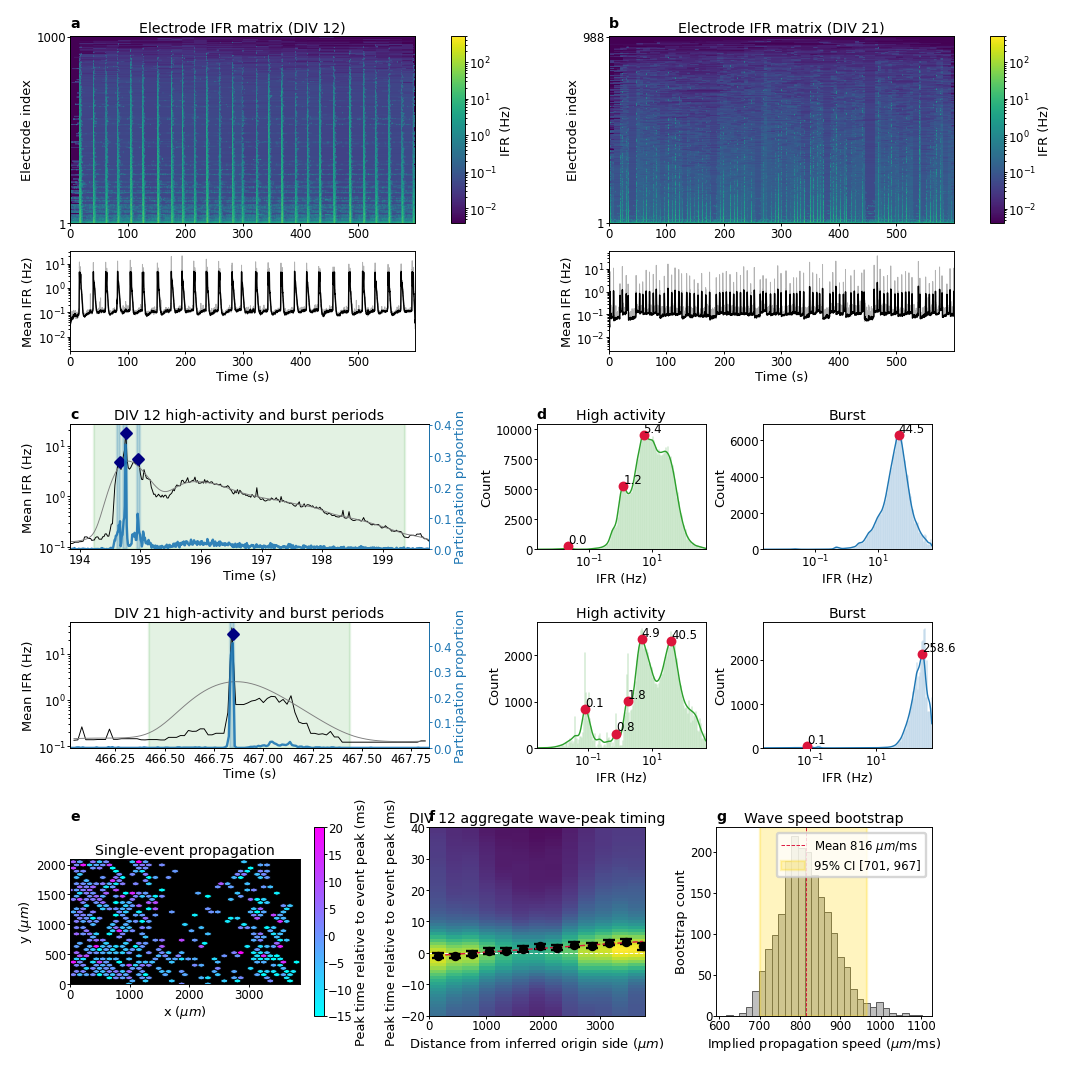

In [23]:
fig2 = compose_figure(
    figure(width="two_column", height_mm=190, rows=[0.5, 0.2, 0.2, 0.3], row_gaps=[0.04, 0.04, 0.05], wspace=0, ncols=26, constrained_layout=False),
    [
        panel(
            "ifr_div12",
            label="a",
            loc=(0, 0, 1, 11),
            draw=draw_population_ifr_summary,
            data=figure2_data["single"][12]["population"],
            axes_factory=population_ifr_summary_axes_factory,
            options={
                "heatmap_title": "Electrode IFR matrix (DIV 12)",
                "mean_title": "",
                "show_titles": True,
                "mean_log_scale": True,
                "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
                "show_legend": False,
            },
        ),
        panel(
            "ifr_div21",
            label="b",
            loc=(0, 15, 1, 11),
            draw=draw_population_ifr_summary,
            data=figure2_data["single"][21]["population"],
            axes_factory=population_ifr_summary_axes_factory,
            options={
                "heatmap_title": "Electrode IFR matrix (DIV 21)",
                "mean_title": "",
                "show_titles": True,
                "mean_log_scale": True,
                "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
                "show_legend": False,
            },
        ),
        panel(
            "burst_div12",
            label="c",
            loc=(1, 0, 1, 10),
            draw=draw_high_activity_burst_windows,
            data=high_activity_panel_data(12),
            options={
                "n_windows": 1,
                "window_order": "peak_ifr",
                "pad_s": BURST_WINDOW_PAD_SEC,
                "show_legend": False,
                "title": "DIV 12 high-activity and burst periods",
                "compact": False,
            },
        ),
        panel(
            "kde_div12",
            label="d",
            loc=(1, 13, 1, 11),
            draw=draw_activity_kde_panel,
            data=figure2_data["activity_kde"][12],
            axes_factory=side_by_side_kde_axes_factory,
            options={"max_peak_labels": 6,
                     "show_legend": False},
        ),
        panel(
            "burst_div21",
            label="",
            loc=(2, 0, 1, 10),
            draw=draw_high_activity_burst_windows,
            data=high_activity_panel_data(21),
            options={
                "n_windows": 1,
                "window_order": "peak_ifr",
                "pad_s": BURST_WINDOW_PAD_SEC,
                "show_legend": False,
                "title": "DIV 21 high-activity and burst periods",
                "compact": False,
            },
        ),
        panel(
            "kde_div21",
            label="",
            loc=(2, 13, 1, 11),
            draw=draw_activity_kde_panel,
            data=figure2_data["activity_kde"][21],
            axes_factory=side_by_side_kde_axes_factory,
            options={"max_peak_labels": 6,
                     "show_legend": False},
        ),
        panel(
            "peak_time_map_div12",
            label="e",
            loc=(3, 0, 1, 8),
            draw=draw_peak_time_map_panel,
            data=figure2_data["peak_time_map"][12],
            options={"compact": False, "show_colorbar": True, "render_mode": "hexbin", "gridsize": 35, "title": "Single-event propagation" },
        ),
        panel(
            "wave_timing_div12",
            label="f",
            loc=(3, 10, 1, 6),
            draw=draw_wave_timing_panel,
            data=figure2_data["wave"][12]["result"],
            options={"compact": True, "show_colorbar": False, "show_legend": False, "title": "DIV 12 aggregate wave-peak timing" },
        ),
        panel(
            "wave_bootstrap_div12",
            label="g",
            loc=(3, 18, 1, 6),
            draw=draw_wave_bootstrap_panel,
            data=figure2_data["wave"][12]["result"],
            options={"compact": True, "show_legend": True, "title": "Wave speed bootstrap" },
        ),
    ],
)

## Paper Reporting CSVs

Writes one methods CSV and one results CSV for paper reporting. The tables are derived from cached Figure 2 activity-state and wave objects.

In [24]:

# Figure 2 paper-facing reporting tables. These summarize cached burst/activity/wave analyses.
REPORT_TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)


def _method_row(parameter, value, meaning, units=""):
    return {
        "figure": "figure_2",
        "parameter": str(parameter),
        "value": str(value),
        "units": str(units),
        "meaning": str(meaning),
    }


def _result_row(section, statistic, value, *, entity="", units="", ci_low=np.nan, ci_high=np.nan, n=np.nan, note=""):
    return {
        "figure": "figure_2",
        "section": str(section),
        "entity": str(entity),
        "statistic": str(statistic),
        "value": value,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "units": str(units),
        "n": n,
        "note": str(note),
    }


method_rows = [
    _method_row("cache_version", CACHE_VERSION, "Version key for Figure 2 cache compatibility."),
    _method_row("wells", WELLS, "Wells included in aggregate activity-state summaries."),
    _method_row("divs", DIVS, "DIVs included in main Figure 2 compilation."),
    _method_row("supp_divs", SUPP_DIVS, "DIVs included in supplementary Figure 2 statistics."),
    _method_row("example_well", EXAMPLE_WELL, "Well used for example panels."),
    _method_row("start_sec", START_SEC, "Start of recording window used for spike-state analysis.", "s"),
    _method_row("end_sec", END_SEC, "End of recording window used for spike-state analysis.", "s"),
    _method_row("top_start", TOP_START, "Lower rank bound for top-electrode selection."),
    _method_row("top_stop", TOP_STOP, "Upper rank bound for top-electrode selection."),
    _method_row("ifr_grid_hz", IFR_GRID_HZ, "Population IFR sampling grid.", "Hz"),
    _method_row("smooth_sigma_sec", SMOOTH_SIGMA_SEC, "Gaussian smoothing sigma for population IFR.", "s"),
    _method_row("high_activity_mad_scale", HIGH_ACTIVITY_MAD_SCALE, "MAD multiplier for high-activity threshold."),
    _method_row("high_activity_min_duration_ms", HIGH_ACTIVITY_MIN_DURATION_MS, "Minimum high-activity epoch duration.", "ms"),
    _method_row("highres_bin_ms", HIGHRES_BIN_MS, "High-resolution spike-trace bin width.", "ms"),
    _method_row("network_bin_ms", NETWORK_BIN_MS, "Participation aggregation bin width.", "ms"),
    _method_row("network_min_participation_fraction", NETWORK_MIN_PARTICIPATION_FRACTION, "Minimum participating-electrode fraction for burst epochs."),
    _method_row("network_min_duration_ms", NETWORK_MIN_DURATION_MS, "Minimum participation burst duration.", "ms"),
    _method_row("wave_div", WAVE_DIV, "DIV used for burst-wave timing panel."),
    _method_row("wave_x_bin_um", WAVE_X_BIN_UM, "X-position bin width for wave timing.", "um"),
    _method_row("wave_bootstrap_reps", WAVE_BOOTSTRAP_REPS, "Bootstrap replicates for wave-speed confidence intervals."),
]

result_rows = []
for div in DIVS:
    single = figure2_data.get("single", {}).get(div, {})
    kde = figure2_data.get("activity_kde", {}).get(div, {})
    entity = f"DIV {div}"
    if single:
        result_rows.extend([
            _result_row("activity_state_detection", "n_high_activity_epochs_example_well", len(single.get("high_activity_epochs", [])), entity=entity, units="epochs"),
            _result_row("activity_state_detection", "n_burst_epochs_example_well", len(single.get("burst_epochs", [])), entity=entity, units="epochs"),
            _result_row("activity_state_detection", "high_activity_threshold_hz_example_well", single.get("high_activity_info", {}).get("threshold_hz", np.nan), entity=entity, units="Hz"),
        ])
    values = kde.get("values", {}) if isinstance(kde, dict) else {}
    for state, state_values in values.items():
        arr = np.asarray(state_values, dtype=float)
        arr = arr[np.isfinite(arr)]
        state_entity = f"DIV {div}; state={state}"
        result_rows.extend([
            _result_row("activity_state_ifr", "n_samples", arr.size, entity=state_entity, units="samples"),
            _result_row("activity_state_ifr", "median_hz", float(np.nanmedian(arr)) if arr.size else np.nan, entity=state_entity, units="Hz"),
            _result_row("activity_state_ifr", "mean_hz", float(np.nanmean(arr)) if arr.size else np.nan, entity=state_entity, units="Hz"),
        ])
    summary_df = kde.get("summary", pd.DataFrame()) if isinstance(kde, dict) else pd.DataFrame()
    if isinstance(summary_df, pd.DataFrame) and not summary_df.empty:
        for _, summary_row in summary_df.iterrows():
            entity = f"DIV {int(summary_row['div'])}; well={int(summary_row['well'])}"
            for col in ["n_refs", "n_high_activity_periods", "n_bursts", "high_activity_threshold_hz"]:
                if col in summary_row:
                    units = "Hz" if col.endswith("_hz") else "count"
                    result_rows.append(_result_row("recording_activity_summary", col, summary_row[col], entity=entity, units=units))
    summaries = kde.get("kde_results", kde.get("summaries", kde.get("kde", {}))) if isinstance(kde, dict) else {}
    if isinstance(summaries, dict):
        for state, summary in summaries.items():
            if not isinstance(summary, dict):
                continue
            peaks = np.asarray(summary.get("peak_hz", summary.get("peaks_hz", [])), dtype=float)
            counts = np.asarray(summary.get("peak_counts", []), dtype=float)
            for rank, peak_hz in enumerate(peaks, start=1):
                count = counts[rank - 1] if rank - 1 < counts.size else np.nan
                result_rows.append(_result_row("activity_state_kde_peaks", f"peak_{rank}_hz", float(peak_hz), entity=f"DIV {div}; state={state}", units="Hz", n=count))

for div in SUPP_DIVS:
    wave = figure2_data.get("wave", {}).get(div, {})
    if isinstance(wave, dict) and wave.get("result") is not None:
        fit_summary = getattr(wave["result"], "fit_summary", pd.DataFrame())
        if isinstance(fit_summary, pd.DataFrame) and not fit_summary.empty:
            row = fit_summary.iloc[0]
            for col, units in {
                "n_events_used": "events",
                "n_events_left_to_right": "events",
                "n_events_right_to_left": "events",
                "implied_speed_um_per_ms": "um/ms",
                "bootstrap_speed_ci_low_um_per_ms": "um/ms",
                "bootstrap_speed_ci_high_um_per_ms": "um/ms",
                "slope_ms_per_um": "ms/um",
                "intercept_ms": "ms",
            }.items():
                if col in row:
                    result_rows.append(_result_row("burst_wave_timing", col, row[col], entity=f"DIV {div}", units=units))

        diagnostics = wave_fit_diagnostics(wave["result"])
        for col in ["fit_r_value", "fit_r_squared", "fit_weighted_r_squared"]:
            result_rows.append(_result_row("burst_wave_fit_diagnostics", col, diagnostics.get(col, np.nan), entity=f"DIV {div}"))

        bootstrap = getattr(wave["result"], "bootstrap_summary", pd.DataFrame())
        if isinstance(bootstrap, pd.DataFrame) and not bootstrap.empty:
            for _, row in bootstrap.iterrows():
                entity = f"DIV {div}"
                for col in bootstrap.columns:
                    if np.isscalar(row[col]):
                        result_rows.append(_result_row("burst_wave_bootstrap", col, row[col], entity=entity))

supp_per_recording, supp_by_div, supp_wave_aggregate, supp_significance = figure2_supplementary_tables()
for _, row in supp_by_div.iterrows():
    entity = f"DIV {int(row['div'])}"
    metric = str(row["metric"])
    result_rows.append(_result_row("supplementary_activity_wave_stats", f"{metric}_mean", row["mean"], entity=entity, ci_low=row["ci_low"], ci_high=row["ci_high"], n=row["n_recordings"], note="Bootstrap 95% CI for DIV mean in ci_low/ci_high columns"))

supp_per_recording.to_csv(REPORT_TABLE_DIR / "figure2_supplementary_per_recording.csv", index=False)
supp_by_div.to_csv(REPORT_TABLE_DIR / "figure2_supplementary_by_div.csv", index=False)
supp_wave_aggregate.to_csv(REPORT_TABLE_DIR / "figure2_supplementary_wave_aggregate.csv", index=False)
supp_significance.to_csv(REPORT_TABLE_DIR / "figure2_supplementary_neighbor_significance.csv", index=False)

figure2_methods_df = pd.DataFrame(method_rows)
figure2_results_df = pd.DataFrame(result_rows)
figure2_methods_df.to_csv(REPORT_TABLE_DIR / "figure2_methods.csv", index=False)
figure2_results_df.to_csv(REPORT_TABLE_DIR / "figure2_results.csv", index=False)
print(f"Saved Figure 2 paper reporting CSVs to {REPORT_TABLE_DIR}")
print("Saved supplementary tables: figure2_supplementary_per_recording.csv, figure2_supplementary_by_div.csv, figure2_supplementary_wave_aggregate.csv, figure2_supplementary_neighbor_significance.csv")
display(figure2_methods_df)
display(figure2_results_df.head(30))
display(supp_by_div)


Saved Figure 2 paper reporting CSVs to /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/tables
Saved supplementary tables: figure2_supplementary_per_recording.csv, figure2_supplementary_by_div.csv, figure2_supplementary_wave_aggregate.csv, figure2_supplementary_neighbor_significance.csv


,figure,parameter,value,units,meaning
0,figure_2,cache_version,figure2_burst_v5_supp_all_divs,,Version key for Figure 2 cache compatibility.
1,figure_2,wells,"[0, 1, 2, 3, 4, 5]",,Wells included in aggregate activity-state sum...
2,figure_2,divs,"[12, 21]",,DIVs included in main Figure 2 compilation.
3,figure_2,supp_divs,"[12, 14, 21, 22, 23, 26]",,DIVs included in supplementary Figure 2 statis...
4,figure_2,example_well,0,,Well used for example panels.
5,figure_2,start_sec,0.0,s,Start of recording window used for spike-state...
6,figure_2,end_sec,600.0,s,End of recording window used for spike-state a...
7,figure_2,top_start,0,,Lower rank bound for top-electrode selection.
8,figure_2,top_stop,1000,,Upper rank bound for top-electrode selection.
9,figure_2,ifr_grid_hz,50.0,Hz,Population IFR sampling grid.


,figure,section,entity,statistic,value,ci_low,ci_high,units,n,note
0,figure_2,activity_state_detection,DIV 12,n_high_activity_epochs_example_well,27.000000,NaN,NaN,epochs,NaN,
1,figure_2,activity_state_detection,DIV 12,n_burst_epochs_example_well,128.000000,NaN,NaN,epochs,NaN,
2,figure_2,activity_state_detection,DIV 12,high_activity_threshold_hz_example_well,0.182375,NaN,NaN,Hz,NaN,
3,figure_2,activity_state_ifr,DIV 12; state=high_activity,n_samples,740311.000000,NaN,NaN,samples,NaN,
4,figure_2,activity_state_ifr,DIV 12; state=high_activity,median_hz,8.912656,NaN,NaN,Hz,NaN,
5,figure_2,activity_state_ifr,DIV 12; state=high_activity,mean_hz,20.517325,NaN,NaN,Hz,NaN,
6,figure_2,activity_state_ifr,DIV 12; state=burst,n_samples,275026.000000,NaN,NaN,samples,NaN,
7,figure_2,activity_state_ifr,DIV 12; state=burst,median_hz,39.682540,NaN,NaN,Hz,NaN,
8,figure_2,activity_state_ifr,DIV 12; state=burst,mean_hz,58.050234,NaN,NaN,Hz,NaN,
9,figure_2,recording_activity_summary,DIV 12; well=0,n_refs,1000.000000,NaN,NaN,count,NaN,


,div,metric,n_recordings,mean,ci_low,ci_high,median,iqr_low,iqr_high,minimum,maximum
0,12,n_high_activity_periods_per_min,6,2.683333,2.366667,2.966667,2.80,2.400,2.975,2.1,3.1
1,14,n_high_activity_periods_per_min,6,2.550000,2.233333,2.916667,2.50,2.250,2.750,2.0,3.3
2,21,n_high_activity_periods_per_min,6,9.633333,8.682917,10.667500,9.20,8.625,10.600,8.2,11.7
3,22,n_high_activity_periods_per_min,6,11.016667,9.166250,13.066667,10.45,9.150,12.650,8.3,14.8
4,23,n_high_activity_periods_per_min,6,11.533333,9.816667,13.517500,11.15,9.700,12.750,8.7,15.7
...,...,...,...,...,...,...,...,...,...,...,...
73,14,n_events_used,6,134.666667,114.666667,154.000000,132.00,125.000,154.000,92.0,168.0
74,21,n_events_used,6,55.500000,46.500000,65.500000,53.50,47.000,59.250,41.0,79.0
75,22,n_events_used,6,71.500000,59.500000,86.500000,63.50,61.000,78.000,54.0,105.0
76,23,n_events_used,6,52.166667,46.500000,57.833333,52.50,48.000,58.500,40.0,61.0


## Export

/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_burst_compilation.pdf
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_burst_compilation.svg
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_burst_compilation.png
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_supplementary_stats.pdf
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_supplementary_stats.svg
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_supplementary_stats.png


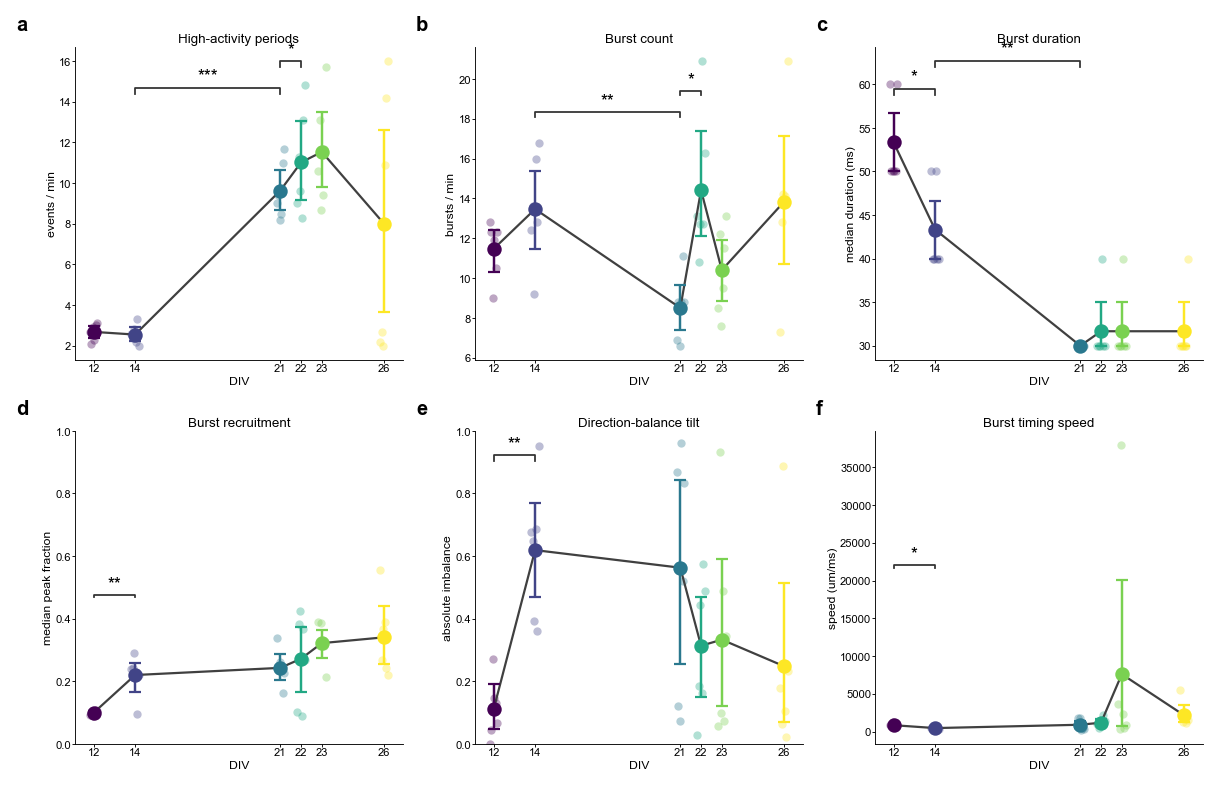

In [25]:
if SAVE_FIGURE:
    saved_paths = export_figure(fig2.fig, OUTPUT_DIR / "figure_2_burst_compilation", formats=("pdf", "svg", "png"))
    for path in saved_paths:
        print(path)

    fig2_supp, supp_per_recording, supp_by_div, supp_wave_aggregate, supp_significance = compose_figure2_supplementary_stats()
    supp_paths = export_figure(fig2_supp, OUTPUT_DIR / "figure_2_supplementary_stats", formats=("pdf", "svg", "png"))
    for path in supp_paths:
        print(path)
